# Visual Wake Word Example



This example demonstrates Image Classification capabilities using the Brainchip's Akida Version 1 architecture.

### 0. Train, Quantize and Convert Model Locally

Follow the [Akida User Guide](https://doc.brainchipinc.com/user_guide/akida.html#overview) to create an Akida 1.0 compatible model prior to testing on Akida Cloud.

Akida Cloud allows you test the capabilities and efficiency of the Akida 1.0 IP without any local hardware setup.

To get the best use of your time on Akida Cloud, it is recommended that you train your model locally by following the Akida workflow and MetaTF.

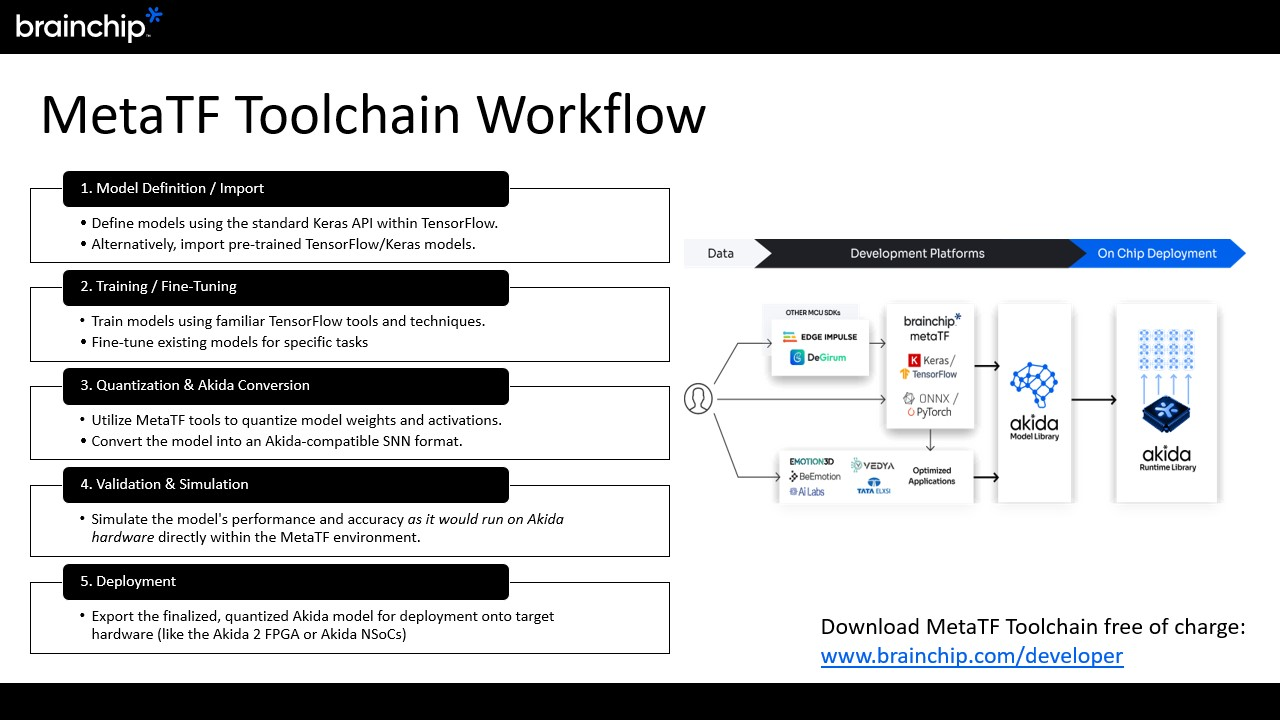

### 1. Import model

The model used for this demonstration can be found at the [Akida 1.0 Model Zoo](https://doc.brainchipinc.com/model_zoo_performance.html#classification). It has been pre-downloaded and converted to Akida here for efficiency.

In [ ]:
from akida_models.model_io import load_model
akida_model = load_model("models/akidanet_vww_iq8_wq4_aq4.fbz")
akida_model.summary()

### 2. Map the model onto the FPGA

For more details on this flow, please see: [Model Hardware Mapping](https://doc.brainchipinc.com/user_guide/akida.html#model-hardware-mapping)

In [ ]:
import akida
from cnn2snn import set_akida_version, AkidaVersion
with set_akida_version(AkidaVersion.v1):
            devices = akida.devices()
            if len(devices) > 0:
                print(f'Available devices: {[dev.desc for dev in devices]}')
                device = devices[0]
                print(device.version)
                try:
                    akida_model.map(device)
                    print(f"Mapping to Akida device {device.desc}.")
                    mappedDevice = device.version
                except Exception as e:
                    print("Model not compatible with Akida 1.0. Running on CPU.")
                    mappedDevice = "CPU"
            else:
                print("No Akida devices found, running on CPU.")
                mappedDevice = "CPU"

#### Model Summary After Mapping

In [ ]:
akida_model.summary()

### 3 Run live inference on a webcam

Here, [Gradio](https://www.gradio.app/) is used to facilitate the capture of live video from a webcam and pass the frames to the Akida model for inference on the FPGA. Classification predictions are displayed for the user in real time.

#### Import Necessary Libraries

This cell imports essential libraries: Gradio for the interface, OpenCV for image processing, the Akida library for model execution, and NumPy and Plotly for data handling and visualization.

In [ ]:
import gradio as gr
import cv2

from cnn2snn import set_akida_version, AkidaVersion
import akida

import numpy as np

import time

import plotly.graph_objects as go

#### Pre/Post Processing and UI functions are defined

In [ ]:
# Defines a function using Plotly to create a gauge visualization for metrics such as
# frames per second during image classification.
def create_gauge(value):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=value,
        gauge={'axis': {'range': [0, 30]}},
        domain={'x': [0, 1], 'y': [0, 1]},
    ))
    fig.update_layout(width=400, height=300)
    return fig

In [ ]:
# Implements a softmax function to convert model outputs into probability distributions.
def softmaxArray(values):
    # Assuming array shape is (1, 1, 1, x), flatten to get the values
    values = values.ravel()
    exp_values = np.exp(values)
    sum_exp = np.sum(exp_values)
    softmax_values = exp_values / sum_exp
    return softmax_values

### Image Configuration and Output Decoding

Sets up image parameters and label names, and includes a function to preprocess images and decode predictions into readable labels.

In [ ]:
# Sets up image parameters and label names, and includes a function to preprocess images
# and decode predictions into readable labels.
image_x = 96
image_y = 96
image_z = 3
labels = ["no person", "person"]
def decodeOutput(inp):
        global akida_model
        inp = cv2.resize(inp, (image_x, image_y))
        inp = inp.reshape((-1, image_x, image_y, image_z))
        timer_start = time.time()
        predictions = softmaxArray(akida_model.predict(inp))
        frame_time = time.time() - timer_start
        fps = 1 / frame_time if frame_time > 0 else 0
        confidences = {labels[i]: predictions[i] for i in range(len(predictions))}

        return confidences, fps

In [ ]:
# A function that processes an image, decodes it, and returns
# classification confidences with a gauge visualization of processing speed.
def classify_image(inp):

  confidences, fps = decodeOutput(inp)

  return confidences, create_gauge(round(fps, 2))

### Gradio Interface Setup

Creates a Gradio interface to capture webcam images, display device information, and stream classified images using the Akida model. The interface shows live predictions and frame processing speeds.

In [ ]:
theme = gr.themes.Base(
    text_size="sm",
    spacing_size="sm",
    radius_size="sm",
)

with gr.Blocks(
    title="Brainchip",
    fill_width=True,
    fill_height=True,
    delete_cache=[180, 600],
    theme=theme
) as demo:
    gr.Markdown("""
        <h1 style="text-align: center;">Akida Cloud</h1>
        <br>
        """)
    with gr.Row():
        gr.Markdown("## Image Classification")
    with gr.Row():
        with gr.Column():
            input_img = gr.Image(sources=["webcam"], type="numpy")
            gr.Markdown("**ℹ️ Please press the 'Record' button to start inference.**")
        with gr.Column():
            gr.Markdown(f"""Device: {mappedDevice}""")
            output_label = gr.Label(num_top_classes=3)
            print(output_label)
            plot = gr.Plot(label="Frames per second")
        dep = input_img.stream(classify_image, [input_img], [output_label, plot],
                                time_limit=30, stream_every=0.1, concurrency_limit=30)        


if __name__ == "__main__":
    demo.launch()